In [16]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
import sys
import os
import numpy as np

sys.path.append(os.path.abspath(".."))

from src.optimization import *
from src.oracles import *
from src.plot_trajectory_2d import *

# Эксперимент 3.2

## Квадратичные функции

### Задаем матрицы

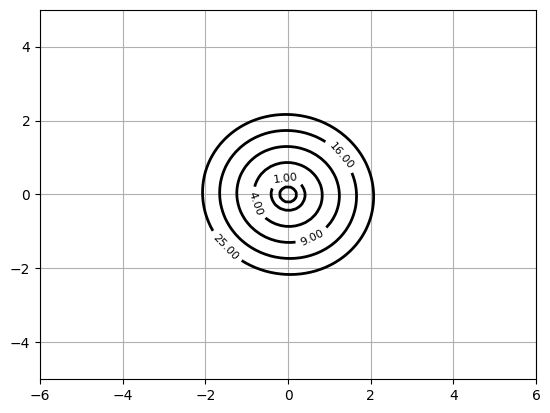

In [37]:
A = np.array(
    [[11.67, 0.29],
    [0.29, 10.67]]
)
b = np.zeros(2)

square_oracle_1 = QuadraticOracle(A, b)
plot_levels(square_oracle_1.func)

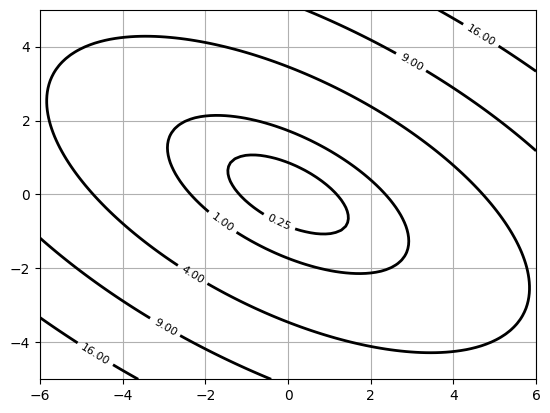

In [38]:
A = np.array(
    [[0.36, 0.29],
    [0.29, 0.67]]
)
b = np.zeros(2)

square_oracle_2 = QuadraticOracle(A, b)
plot_levels(square_oracle_2.func)

### Запускаем методы

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


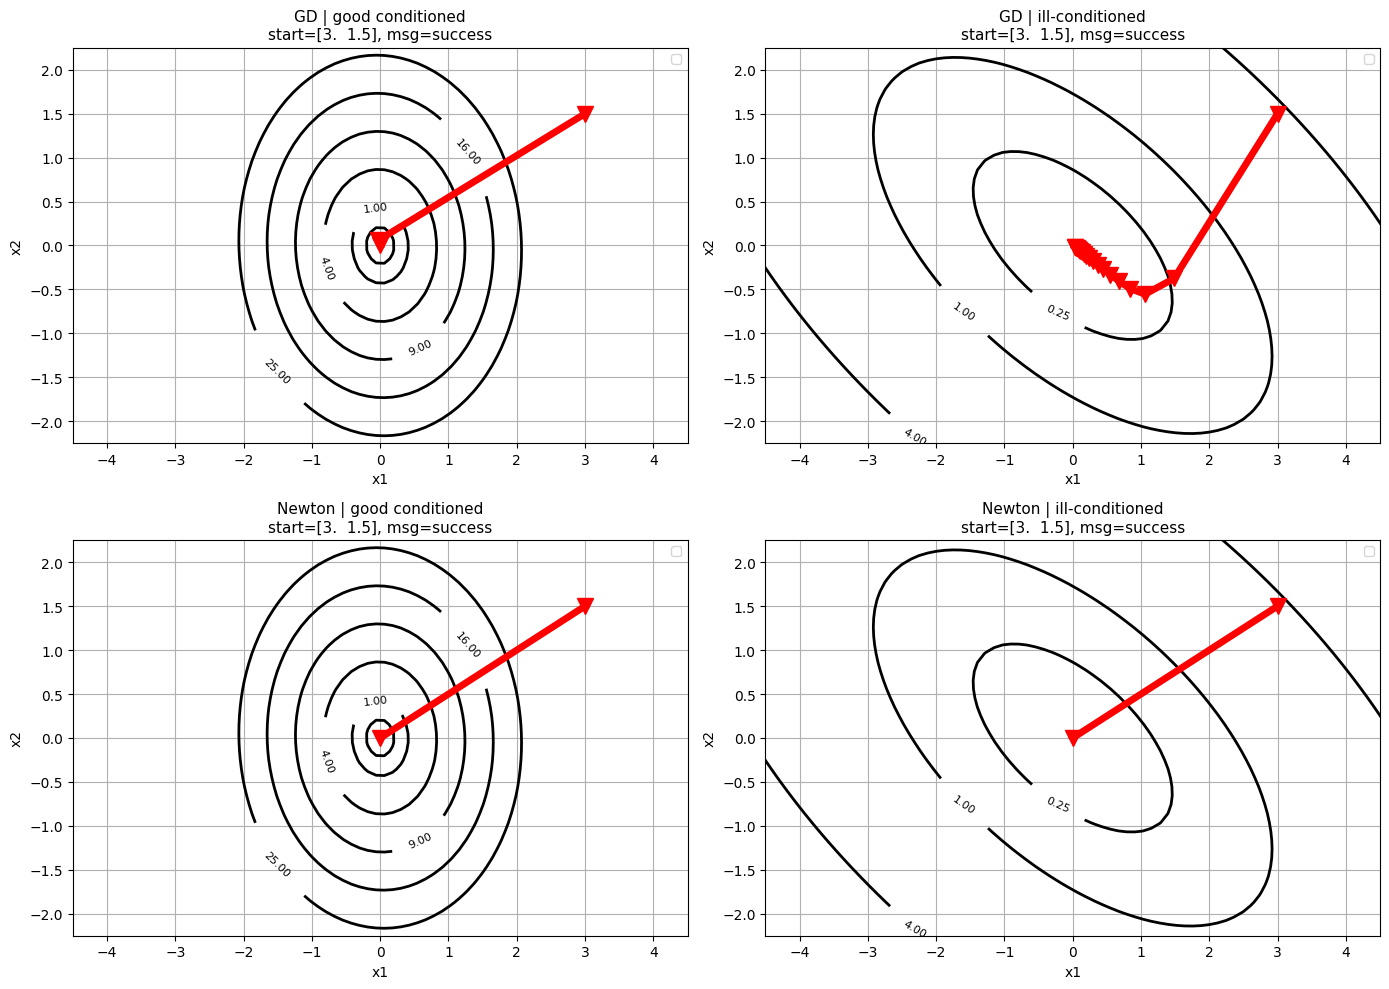

In [68]:
import matplotlib.pyplot as plt

# Если хочешь один и тот же старт для всех:
start_point = np.array([3.0, 1.5])

cases = [
    ("GD | good conditioned", gradient_descent, square_oracle_1),
    ("GD | ill-conditioned",  gradient_descent, square_oracle_2),
    ("Newton | good conditioned", newton, square_oracle_1),
    ("Newton | ill-conditioned",  newton, square_oracle_2),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, (title, method, oracle) in zip(axes, cases):
    plt.sca(ax)  # делаем текущей нужную ось

    x_star, msg, history = method(oracle, start_point, trace=True)

    plot_levels(oracle.func)
    plot_trajectory(oracle.func, list(history['x']), fit_axis=True)

    # Явно отмечаем стартовую точку
    # ax.scatter(start_point[0], start_point[1], c='black', s=100, marker='*', label='start point')

    ax.set_title(f"{title}\nstart={start_point}, msg={msg}", fontsize=11)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.legend(loc="best", fontsize=9)

plt.tight_layout()
plt.show()